In [1]:
import pandas, pathlib

tables_path = pathlib.Path('tables/')
data_path = pathlib.Path('data/')


Let's take a look at the tables we've created. First we have the so-called "master table" which in the schema will becomes `PROCESSED_RUNS` once we've removed the lowercase columns that let us track progress.

We can see the six samples, five of which have a main report and one of these is a mixture as it has two species.  One sample failed to produce a main report and hence the status is undefined. For the others, the status doesn't always make sense as some of these samples were processed before the pipeline was changed to correctly report if an NTM was proceeding to genome. The number of reads is derived from kraken2 and since all the NTMs were processed using FASTQ files that had already been through gatekeeper, they should have no `OTHER_BACTERIAL_READS`.


In [2]:
MASTER_TABLE = pandas.read_csv(tables_path / "TEST_MASTER_TABLE_renamed.csv")
MASTER_TABLE

,RUN_ACCESSION,batch_name,pipeline_version,remote_sample_name,remote_batch_name,remote_batch_id,has_main_report,status,HUMAN_READS,MYCOBACTERIAL_READS,OTHER_BACTERIAL_READS,UNCLASSIFIED_READS,GPAS_PIPELINE_BUILD,has_new_block_in_main_report,NUMBER_OF_SPECIES
0,SRR6981952,TB test batch,2.4.1,0908e4b9-fa2e-4832-b864-58b6e23b53b6,0f0zao,c5bfc0fe-c5ad-48c2-836e-e430d42cf129,True,complete,NaN,1385434.0,2178.0,302.0,5ae3bc4,False,1.0
1,SRR6982035,TB test batch,2.4.1,0f098bfb-f479-4bbe-a5b8-7c607147b475,0f0zao,c5bfc0fe-c5ad-48c2-836e-e430d42cf129,True,cannot assemble,NaN,56182.0,750976.0,1804.0,5ae3bc4,False,1.0
2,bd821678-1865-48bc-a836-8d97a7e99b3d,trial4-mycobacterium-abscessus_batch_51,2.4.1,e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb,0pqwzx,00e3f459-d6a8-4f6d-a9ba-abd210f6b8d5,True,cannot assemble,NaN,2564882.0,0.0,17466.0,68d0e6f,False,1.0
3,77434f41-625f-424a-97c5-8d318ce11410,mixture-test,2.4.1,77434f41-625f-424a-97c5-8d318ce11410,8oruua,48f94831-7896-4127-bfd1-2ce5c5a034e9,True,complete,NaN,2399958.0,0.0,51662.0,fa04ac9,True,2.0
4,05c9ed42-e452-48d9-bee8-993320c428e8,trial4-mycobacterium-avium_batch_42,2.4.1,562ab3e6-b0a7-4b5c-8545-4e287257e4c8,0cwucm,8e3c060b-9d43-48da-a9a0-ddd16eba6044,True,cannot assemble,NaN,1194206.0,0.0,85508.0,5360392,False,1.0
5,05f52b1f-5762-4b0a-9f57-2c5c268b5472,trial4-mycobacterium-avium_batch_42,2.4.1,47bb4d52-e76b-4ee6-96f1-2391b15983a8,0cwucm,8e3c060b-9d43-48da-a9a0-ddd16eba6044,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0


The next table is `SPECIES` which contains one row per species per sample. We can see that the mixture sample has two species, one of which is a *Mycobacterium intracellulare* complex (MAC) and the other is a *Mycobacterium abscessus*. Note that `SPECIES_NAME` here and in all subsequent tables is the name of the mapping reference which may not be quite what you expect. Hence properly we could consider replacing *Mycobacterium tuberculosis* with *Mycobacterium tuberculosis* complex but here it in effect means that the reads were mapped to NC_000962.3 i.e. version 3 of the H37Rv reference genome. We can therefore see situations where the `SPECIES_NAME` is *Mycobacterium tuberculosis* and the `SUBSPECIES_NAME` is *Mycobacterium bovis*. `LINEAGE` and `SUBLINEAGE` are only reported for MBTC.

In [3]:
SPECIES = pandas.read_parquet(tables_path / "SPECIES.parquet")
SPECIES

,SPECIES_NAME,SUBSPECIES_NAME,LINEAGE,SUBLINEAGE,N_READS,COVERAGE,DEPTH,has_predictions,has_effects,has_mutations,has_variants
RUN_ACCESSION,,,,,,,,,,,
05c9ed42-e452-48d9-bee8-993320c428e8,Mycobacterium avium,Mycobacterium avium subsp. hominissuis,NaN,NaN,876374,93.650000,24.494500,False,False,True,True
77434f41-625f-424a-97c5-8d318ce11410,Mycobacterium intracellulare,Mycobacterium intracellulare subsp. intracellu...,NaN,NaN,1806529,93.014100,45.402600,False,False,True,True
77434f41-625f-424a-97c5-8d318ce11410,Mycobacterium avium,NaN,,,217986,90.669900,5.936030,False,False,True,True
SRR6982035,Mycobacterium tuberculosis,Mycobacterium tuberculosis,lineage4,lineage4.3.2.1,55033,78.087900,2.077450,False,False,False,False
SRR6981952,Mycobacterium tuberculosis,Mycobacterium tuberculosis,lineage4,lineage4.3.3,1316132,99.112100,79.112900,True,True,True,True
bd821678-1865-48bc-a836-8d97a7e99b3d,Mycobacterium abscessus,Mycobacterium abscessus subsp. abscessus,NaN,NaN,2432683,99.009063,42.174912,False,False,True,True


Now, let's look at the `VARIANTS` table. This is much larger and has one row per genetic variant per species per sample.

In [4]:
VARIANTS = pandas.read_parquet(tables_path / "VARIANTS.parquet")
VARIANTS

GENE_POSITION  \
RUN_ACCESSION                        SPECIES_NAME            GENE      VARIANT                     
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium     dnaA      137c>g               24.0   
                                                                       191c>a               42.0   
                                                                       338g>g               91.0   
                                                                       405c>g              113.0   
                                                                       410g>g              115.0   
...                                                                                          ...   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus MAB_4895c 5004542t>z          156.0   
                                                                       5004584g>z          142.0   
                                                                       5004596g>z          138.0   
                                                                       5004599a>z          137.0   
                                                                       5004605c>z          135.0   

                                                                                   CODON_IDX  \
RUN_ACCESSION                        SPECIES_NAME            GENE      VARIANT                 
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium     dnaA      137c>g            0.0   
                                                                       191c>a            0.0   
                                                                       338g>g            0.0   
                                                                       405c>g            1.0   
                                                                       410g>g            0.0   
...                                                                                      ...   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus MAB_4895c 5004542t>z        2.0   
                                                                       5004584g>z        2.0   
                                                                       5004596g>z        2.0   
                                                                       5004599a>z        2.0   
                                                                       5004605c>z        2.0   

                                                                                   NUCLEOTIDE_INDEX  \
RUN_ACCESSION                        SPECIES_NAME            GENE      VARIANT                        
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium     dnaA      137c>g                   137   
                                                                       191c>a                   191   
                                                                       338g>g                   338   
                                                                       405c>g                   405   
                                                                       410g>g                   410   
...                                                                                             ...   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus MAB_4895c 5004542t>z           5004542   
                                                                       5004584g>z           5004584   
                                                                       5004596g>z           5004596   
                                                                       5004599a>z           5004599   
                                                                       5004605c>z           5004605   

                                                                                   INDEL_LENGTH  \
RUN_ACCESSION                        SPECIES_NAME            GENE      VARIANT                

In [5]:
VARIANTS[VARIANTS.MINOR_READS == VARIANTS.COVERAGE]

GENE_POSITION  \
RUN_ACCESSION                        SPECIES_NAME                 GENE          VARIANT                     
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium          BJP76_00155   33442g>x             78.0   
                                                                  BJP76_00160   35166c>x            -92.0   
                                                                  BJP76_00865   179654a>x           -12.0   
                                                                  BJP76_23595   279848c>x            23.0   
                                                                  BJP76_01335   281506c>x           424.0   
...                                                                                                   ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium intracellulare LK403_RS26375 5620170g>z           27.0   
                                                                                5620228c>z            7.0   
                                                                                5620229a>z            7.0   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus      nan           1462035c>x            NaN   
                                                                                1462039g>x            NaN   

                                                                                            CODON_IDX  \
RUN_ACCESSION                        SPECIES_NAME                 GENE          VARIANT                 
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium          BJP76_00155   33442g>x          2.0   
                                                                  BJP76_00160   35166c>x          NaN   
                                                                  BJP76_00865   179654a>x         NaN   
                                                                  BJP76_23595   279848c>x         0.0   
                                                                  BJP76_01335   281506c>x         0.0   
...                                                                                               ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium intracellulare LK403_RS26375 5620170g>z        0.0   
                                                                                5620228c>z        2.0   
                                                                                5620229a>z        1.0   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus      nan           1462035c>x        NaN   
                                                                                1462039g>x        NaN   

                                                                                            NUCLEOTIDE_INDEX  \
RUN_ACCESSION                        SPECIES_NAME                 GENE          VARIANT                        
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium avium          BJP76_00155   33442g>x               33442   
                                                                  BJP76_00160   35166c>x               35166   
                                                                  BJP76_00865   179654a>x             179654   
                                                                  BJP76_23595   279848c>x             279848   
                                                                  BJP76_01335   281506c>x             281506   
...                                                                                                      ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium intracellulare LK403_RS26375 5620170g>z           5620170   
                                                                                5620228c>z           5620228   
                                                                                5620229a>z           5620229   
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus      nan       

Crudely grouping we can see that some species in our test suite have many more variants than others. This is likely to complicate the final tables as for some species they may end up being very large. This is another way of saying "what is the average SNP distance between a sample and its reference?". 

In [6]:
VARIANTS.reset_index(inplace=True)
VARIANTS[["RUN_ACCESSION", "SPECIES_NAME", "VARIANT"]].groupby(["RUN_ACCESSION", "SPECIES_NAME"]).count()

/tmp/ipykernel_3374247/1560629916.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  VARIANTS[["RUN_ACCESSION", "SPECIES_NAME", "VARIANT"]].groupby(["RUN_ACCESSION", "SPECIES_NAME"]).count()


VARIANT
RUN_ACCESSION                        SPECIES_NAME                         
562ab3e6-b0a7-4b5c-8545-4e287257e4c8 Mycobacterium abscessus             0
                                     Mycobacterium avium             40281
                                     Mycobacterium intracellulare        0
                                     Mycobacterium tuberculosis          0
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium abscessus             0
                                     Mycobacterium avium             55940
                                     Mycobacterium intracellulare   100155
                                     Mycobacterium tuberculosis          0
e2375fb6-a3fe-49bc-8b17-6cdb0d8e9ecb Mycobacterium abscessus           135
                                     Mycobacterium avium                 0
                                     Mycobacterium intracellulare        0
                                     Mycobacterium tuberculosis          0
final                                Mycobacterium abscessus             0
                                     Mycobacterium avium                 0
                                     Mycobacterium intracellulare        0
                                     Mycobacterium tuberculosis       1373

Translating these into amino acids as appropriate yields the `MUTATIONS` table.

In [7]:
MUTATIONS = pandas.read_parquet(tables_path / "MUTATIONS-CORRECTED.parquet")
MUTATIONS

GENE_POSITION  \
RUN_ACCESSION                        SPECIES_NAME               GENE  MUTATION                  
final                                Mycobacterium tuberculosis PE1   N123K             123.0   
                                                                      L485L             485.0   
                                                                PE2   G291E             291.0   
                                                                PE23  Q328R             328.0   
                                                                PE3   T14A               14.0   
...                                                                                       ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium avium        zwf_2 F360Z             360.0   
                                                                      Y361Z             361.0   
                                                                      R367Z             367.0   
                                                                      R371Z             371.0   
                                                                      T373Z             373.0   

                                                                                REF  \
RUN_ACCESSION                        SPECIES_NAME               GENE  MUTATION        
final                                Mycobacterium tuberculosis PE1   N123K     aac   
                                                                      L485L     ctg   
                                                                PE2   G291E     ggg   
                                                                PE23  Q328R     cag   
                                                                PE3   T14A      acg   
...                                                                             ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium avium        zwf_2 F360Z     ttc   
                                                                      Y361Z     tac   
                                                                      R367Z     cgc   
                                                                      R371Z     agg   
                                                                      T373Z     acc   

                                                                                ALT  \
RUN_ACCESSION                        SPECIES_NAME               GENE  MUTATION        
final                                Mycobacterium tuberculosis PE1   N123K     aaa   
                                                                      L485L     ttg   
                                                                PE2   G291E     gag   
                                                                PE23  Q328R     cgg   
                                                                PE3   T14A      gcg   
...                                                                             ...   
77434f41-625f-424a-97c5-8d318ce11410 Mycobacterium avium        zwf_2 F360Z     tcc   
                                                                      Y361Z     tcc   
                                                                      R367Z     ctc   
                                                                      R371Z     agg   
                                                                      T373Z     ccc   

                                                                                NUCLEOTIDE_NUMBER  \
RUN_ACCESSION                        SPECIES_NAME               GENE  MUTATION                      
final                                Mycobacterium tuberculosis PE1   N123K                   NaN   
                                                                      L485L                   NaN   
                                                                PE2   G291E                   NaN   
                                                 

We can, for example, plot the `FRS` histogram for all the minor mutations. Clockwork's definition of a minor mutation is one where the FRS<0.9.

<Axes: >

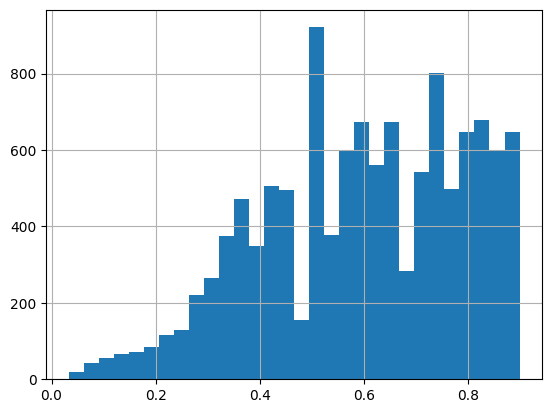

In [8]:
MUTATIONS.FRS.hist(bins=30)

Now we can look at the proportion of reads by species that are minor. Taking TB as a baseline (via v3.4.0) we find about 10.4% of reads are reported as minor. Whilst this obviously depends on sequencing quality and sample preparation we see the *M. avium* sample has a much higher proportion of minor reads. Need to see if this is borne out more broadly but, if true, is another factor that will inflate the sizes of the tables for some species.

In [9]:
MUTATIONS.reset_index(inplace=True)
pandas.crosstab(MUTATIONS.SPECIES_NAME, MUTATIONS.IS_MINOR)

IS_MINOR,False,True
SPECIES_NAME,,
Mycobacterium abscessus,99,26
Mycobacterium avium,55468,11195
Mycobacterium intracellulare,71047,694
Mycobacterium tuberculosis,1213,22
